In [1]:
# Import libraries for expanded evaluation metrics and price-band analysis
import pandas as pd
import numpy as np

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt

In [2]:
# Load the same time-based split, and refit the best model from Week 7 so we have predictions to evaluate
from xgboost import XGBRegressor

train_df = pd.read_csv("output/train.csv")
test_df = pd.read_csv("output/test.csv")

X_train_full = train_df.drop(columns=["ClosePrice"])
y_train = train_df["ClosePrice"]
X_test_full = test_df.drop(columns=["ClosePrice"])
y_test = test_df["ClosePrice"]

# best params found during Week 7 tuning
best_model = XGBRegressor(max_depth=7, learning_rate=0.1, n_estimators=300, random_state=42, n_jobs=-1)
best_model.fit(X_train_full, y_train)

y_pred = best_model.predict(X_test_full)
print("Predictions generated for", len(y_pred), "test rows")

Predictions generated for 12434 test rows


In [3]:
# MAPE: average percentage error. MdAPE: median percentage error (more robust to outliers than MAPE)
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def mdape(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true)) * 100

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape_val = mape(y_test, y_pred)
mdape_val = mdape(y_test, y_pred)

print("Overall Test Metrics")
print("---------------------")
print(f"R²:     {r2:.4f}")
print(f"MAE:    ${mae:,.0f}")
print(f"RMSE:   ${rmse:,.0f}")
print(f"MAPE:   {mape_val:.2f}%")
print(f"MdAPE:  {mdape_val:.2f}%")

Overall Test Metrics
---------------------
R²:     0.8502
MAE:    $205,150
RMSE:   $330,286
MAPE:   18.72%
MdAPE:  12.24%


In [4]:
# Split test set into price bands (quintiles) based on actual sale price, to see where the model performs best/worst
results = pd.DataFrame({"y_true": y_test.values, "y_pred": y_pred})
results["abs_pct_error"] = np.abs((results["y_true"] - results["y_pred"]) / results["y_true"]) * 100

results["price_band"] = pd.qcut(
    results["y_true"],
    q=5,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"]
)

results.head()

,y_true,y_pred,abs_pct_error,price_band
0,2185000.0,1.896140e+06,13.220120,Q5 (highest)
1,500000.0,7.729024e+05,54.580487,Q1 (lowest)
2,1500000.0,1.748411e+06,16.560725,Q4
3,3885000.0,3.375900e+06,13.104234,Q5 (highest)
4,3885000.0,3.630278e+06,6.556551,Q5 (highest)


In [11]:
# Compute R², MAE, MAPE, MdAPE separately within each price band
band_metrics = []
for band in results["price_band"].cat.categories:
    band_df = results[results["price_band"] == band]
    band_metrics.append({
        "Price_Band": band,
        "Count": len(band_df),
        "Price_Range": f"${band_df['y_true'].min():,.0f} - ${band_df['y_true'].max():,.0f}",
        "MAE": mean_absolute_error(band_df["y_true"], band_df["y_pred"]),
        "MAPE": band_df["abs_pct_error"].mean(),
        "MdAPE": band_df["abs_pct_error"].median(),
    })

band_metrics_df = pd.DataFrame(band_metrics)
band_metrics_df

,Price_Band,Count,Price_Range,MAE,MAPE,MdAPE
0,Q1 (lowest),2509,"$26,000 - $580,000",93847.132271,27.251674,13.699012
1,Q2,2478,"$580,235 - $805,000",117580.599475,16.958598,11.096844
2,Q3,2473,"$806,000 - $1,115,000",154001.514016,16.425883,11.025309
3,Q4,2487,"$1,116,000 - $1,675,525",213266.528297,15.668576,12.106436
4,Q5 (highest),2487,"$1,677,000 - $3,885,000",447432.839063,17.176509,14.343490


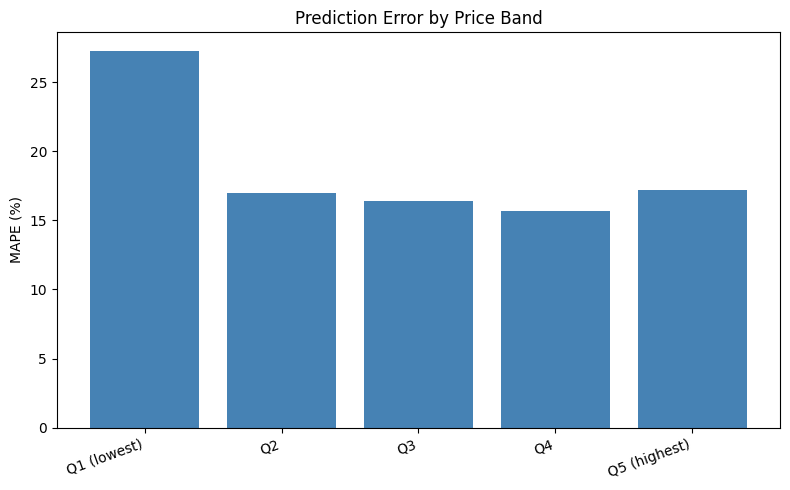

In [6]:
# Visualize how error rate changes across price bands
plt.figure(figsize=(8, 5))
plt.bar(band_metrics_df["Price_Band"], band_metrics_df["MAPE"], color="steelblue")
plt.ylabel("MAPE (%)")
plt.title("Prediction Error by Price Band")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

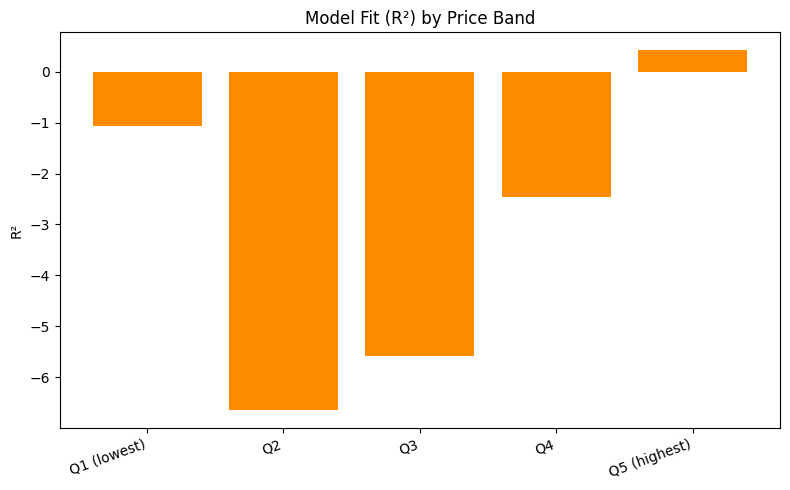

In [7]:
# Visualize how well the model explains variance within each price band
plt.figure(figsize=(8, 5))
plt.bar(band_metrics_df["Price_Band"], band_metrics_df["R2"], color="darkorange")
plt.ylabel("R²")
plt.title("Model Fit (R²) by Price Band")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [8]:
# Combine overall metrics into a single-row summary table
overall_summary = pd.DataFrame([{
    "Segment": "Overall",
    "Count": len(y_test),
    "R2": r2,
    "MAE": mae,
    "RMSE": rmse,
    "MAPE": mape_val,
    "MdAPE": mdape_val,
}])
overall_summary

,Segment,Count,R2,MAE,RMSE,MAPE,MdAPE
0,Overall,12434,0.850151,205149.770883,330286.342311,18.7152,12.242027


In [9]:
# Combine overall metrics with per-price-band metrics into a single summary table for export
band_summary = band_metrics_df.rename(columns={"Price_Band": "Segment"})[["Segment", "Count", "R2", "MAE", "MAPE", "MdAPE"]]
metrics_summary = pd.concat([overall_summary.drop(columns=["RMSE"]), band_summary], ignore_index=True)
metrics_summary

,Segment,Count,R2,MAE,MAPE,MdAPE
0,Overall,12434,0.850151,205149.770883,18.715200,12.242027
1,Q1 (lowest),2509,-1.067775,93847.132271,27.251674,13.699012
2,Q2,2478,-6.632450,117580.599475,16.958598,11.096844
3,Q3,2473,-5.582303,154001.514016,16.425883,11.025309
4,Q4,2487,-2.452241,213266.528297,15.668576,12.106436
5,Q5 (highest),2487,0.416943,447432.839063,17.176509,14.343490


In [10]:
# Save the full metrics summary (overall + by price band) as the Week 8 deliverable
metrics_summary.to_csv("output/metrics_summary.csv", index=False)
print("Saved output/metrics_summary.csv")

Saved output/metrics_summary.csv


#### Insights: Which Price Bands Perform Better

- **Overall model performance:** The model achieved an R² of 0.85, MAPE of 18.72%, and MdAPE of 12.24%.

- **Best-performing band:** Q3 (USD 806K-1.115M) has the lowest MAPE (16.43%) and lowest MdAPE (11.03%). This is the middle price range, where the dataset contains the most homes, giving the model more examples to learn from and leading to better predictions.

- **Worst-performing band:** Q1 (USD 26K–580K) has the highest MAPE (27.25%), even though it has the lowest MAE (USD 93,847). This happens because percentage error is larger for lower-priced homes. The same dollar error represents a much bigger percentage on a USD 200K home than on a USD 2M home.

  On the other hand, Q5 (USD 1.68M–3.885M) has a moderate MAPE (17.18%) but the highest MAE (USD 447K), meaning prediction errors are much larger in dollar value. This is likely because there are fewer luxury homes in the training data and they vary more in features.

- **Practical takeaway:** Q1 has the largest percentage errors, while Q5 has the largest dollar errors. If the model is used for pricing decisions, it may be helpful to use wider confidence ranges for homes at both ends of the price spectrum or consider a separate model for luxury homes.

- **Note**: R² was not included for each price band because it can be misleading when calculated within a narrow price range. Since prices vary less within each band, R² often becomes negative even when prediction errors are reasonable. MAE, MAPE, and MdAPE provide a more reliable measure of performance for these groups.